# BrushCue Example: Gaussian Blur

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/gaussian_blur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/gaussian-blur

In [ ]:
!pip install brushcue

creating texture TextureKey { size: (1739, 2160, 1), format: Rgba8Unorm, usage_style: Storage }
creating texture TextureKey { size: (1792, 2304, 1), format: Rgba8Unorm, usage_style: Render { sample_count: 1 } }
creating texture TextureKey { size: (1792, 2304, 1), format: Rgba8Unorm, usage_style: Render { sample_count: 4 } }
creating texture TextureKey { size: (1792, 2304, 1), format: Rgba16Float, usage_style: Storage }
creating texture TextureKey { size: (1792, 2304, 1), format: Rgba16Float, usage_style: Storage }
creating texture TextureKey { size: (1792, 2304, 1), format: Rgba16Float, usage_style: Storage }
creating texture TextureKey { size: (1731, 2152, 1), format: Rgba16Float, usage_style: Storage }
creating texture TextureKey { size: (1792, 2304, 1), format: Rgba16Float, usage_style: Storage }


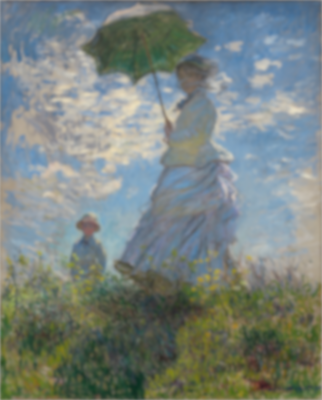

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
sigma_2 = brushcue.float_passthrough(8.0)
float_divide_3 = brushcue.float_divide(sigma_2, 2.0)
float_divide_4 = brushcue.float_divide(sigma_2, 2.0)
composition_bounds_5 = brushcue.composition_bounds(input_image_1)
composition_bounds_6 = brushcue.composition_bounds(input_image_1)
composition_bounds_7 = brushcue.composition_bounds(input_image_1)
composition_bounds_8 = brushcue.composition_bounds(input_image_1)
gaussian_blur_9 = brushcue.composition_gaussian_blur(input_image_1, sigma_2)
bounds2f_min_x_10 = brushcue.bounds2f_min_x(composition_bounds_5)
bounds2f_min_y_11 = brushcue.bounds2f_min_y(composition_bounds_6)
bounds2f_width_12 = brushcue.bounds2f_width(composition_bounds_7)
bounds2f_height_13 = brushcue.bounds2f_height(composition_bounds_8)
float_add_14 = brushcue.float_add(bounds2f_min_x_10, float_divide_3)
float_add_15 = brushcue.float_add(bounds2f_min_y_11, float_divide_4)
float_subtract_16 = brushcue.float_subtract(bounds2f_width_12, sigma_2)
float_subtract_17 = brushcue.float_subtract(bounds2f_height_13, sigma_2)
bounds_2d_float_from_x_y_width_height_18 = brushcue.bounds2f_from_x_y_width_height(float_add_14, float_add_15, float_subtract_16, float_subtract_17)
crop_to_avoid_transparent_edges_19 = brushcue.composition_crop(gaussian_blur_9, bounds_2d_float_from_x_y_width_height_18)

ctx = brushcue.Context()
result = crop_to_avoid_transparent_edges_19.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
